In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=10)
X

array([[ 0.19924745, -0.11697552],
       [-0.24882029, -0.73115232],
       [-0.3544904 , -0.7081059 ],
       [-1.59086506, -2.01199214],
       [-0.20083951,  1.63493163],
       [-0.83241122,  0.15599044],
       [-1.79207014,  1.07782053],
       [ 0.0856607 ,  0.80626713],
       [-0.55865299,  0.74859527],
       [-1.95974262,  0.75152794],
       [-1.77828947, -0.90114581],
       [-1.77985853, -0.1815243 ],
       [-0.02194151, -2.98092432],
       [ 0.80563431,  1.20500136],
       [-1.82701214,  0.78302407],
       [ 0.38730728,  0.42968688],
       [-0.14108668, -0.73229726],
       [-1.87955941, -0.83930476],
       [-0.18232911,  0.83727062],
       [-1.77059533, -0.10255323],
       [-2.27658028,  0.65867001],
       [-2.06519502,  0.92649819],
       [-1.31690551,  0.10216193],
       [ 1.61043259,  0.46886454],
       [-1.21650394,  0.45432938],
       [ 0.6139723 ,  1.8613386 ],
       [-1.78760957, -0.79255991],
       [-1.04149161, -1.0004391 ],
       [-2.40067584,

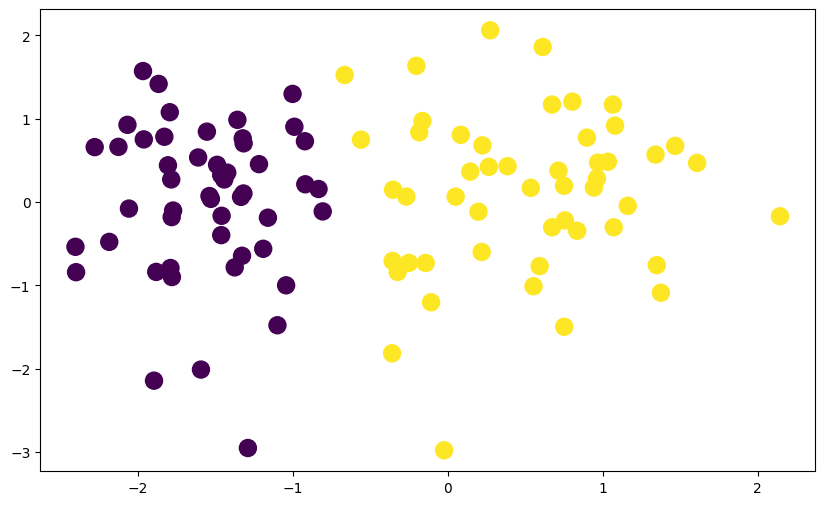

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,s=150)

In [ ]:
def step(z):
    return 1 if z>0 else 0

In [ ]:
def perceptron(X,y):

    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]

    return weights[0],weights[1:]

In [ ]:
intercept_,coef_ = perceptron(X,y)

In [ ]:
print(coef_)
print(intercept_)

[1.38192026 0.08256056]
0.9


In [ ]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [ ]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

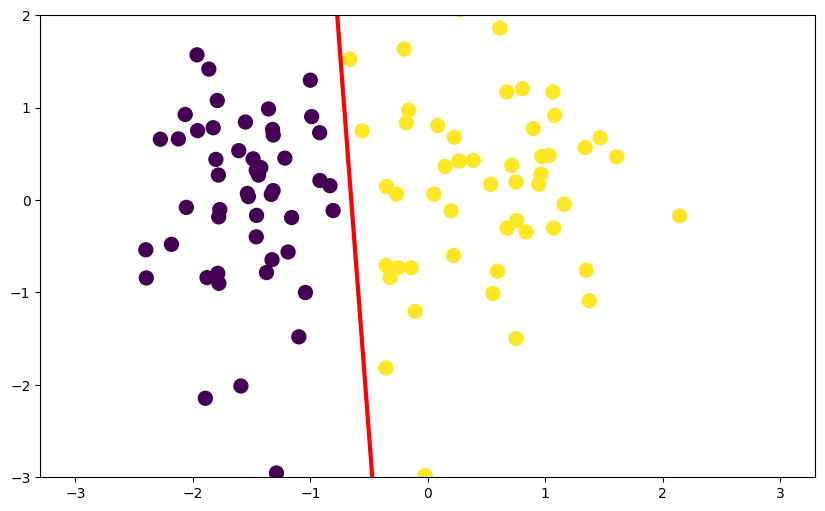

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,s=100)
plt.ylim(-3,2)

In [ ]:
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.inspection import DecisionBoundaryDisplay

In [ ]:
# Step 1: Create the Financial Dataset
# ---------------------------------------------------------
# Feature 1: Earnings Per Share (Higher is better)
# Feature 2: Debt-to-Equity Ratio (Lower is better)

# Safe Companies (High EPS, Low Debt)
safe_companies = np.array([
    [5.2, 0.5], [6.1, 0.4], [4.8, 0.6], [7.0, 0.2], [5.5, 0.5]
])
safe_labels = np.ones(5) # Class 1

# Risky Companies (Low EPS, High Debt)
risky_companies = np.array([
    [1.2, 2.5], [0.8, 3.0], [2.1, 2.1], [1.5, 2.8], [0.5, 3.5]
])
risky_labels = np.zeros(5) # Class 0

# Combine datasets
X = np.vstack((safe_companies, risky_companies))
y = np.concatenate((safe_labels, risky_labels))

X

array([[5.2, 0.5],
       [6.1, 0.4],
       [4.8, 0.6],
       [7. , 0.2],
       [5.5, 0.5],
       [1.2, 2.5],
       [0.8, 3. ],
       [2.1, 2.1],
       [1.5, 2.8],
       [0.5, 3.5]])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Perceptron(max_iter=1000, eta0=0.1, tol=1e-3, random_state=42)
model.fit(X_train, y_train)

Perceptron(eta0=0.1, random_state=42)

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")


Model Accuracy: 100.00%


In [ ]:
print(f"Learned Weights (w1, w2): {model.coef_[0]}")
print(f"Learned Bias (Intercept): {model.intercept_[0]}")


Learned Weights (w1, w2): [ 0.26 -0.46]
Learned Bias (Intercept): -0.1


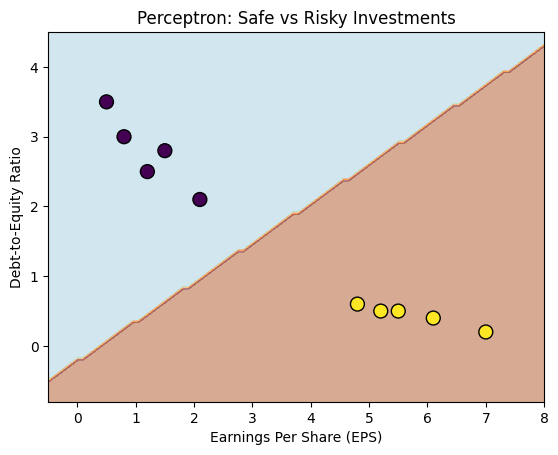

In [ ]:
display = DecisionBoundaryDisplay.from_estimator(model, X, response_method="predict", cmap=plt.cm.Paired, alpha=0.5)
display.ax_.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", s=100)
plt.title("Perceptron: Safe vs Risky Investments")
plt.xlabel("Earnings Per Share (EPS)")
plt.ylabel("Debt-to-Equity Ratio")
plt.show()